# Proyecto 2 - Análisis Exploratorio de Datos (EDA) Inicial
## Dataset 4: Propiedades Estructurales y Actividad de Proteínas (Dominio: Ciencias Ómicas / Biotecnología)

* **Fuente:** Datos moleculares tabulados provenientes del Protein Data Bank (PDB) y UniProt / Kaggle.
* **Tipo de Datos:** Frecuencias de composición molecular, variables físicas, datos de estabilidad y etiquetas taxonómicas.
* **Descripción:** Mapeo de descriptores fisicoquímicos derivados de secuencias de aminoácidos estructurales de proteínas (incluyendo proteomas fúngicos). Incluye peso molecular, punto isoeléctrico, estabilidad y frecuencias de residuos.
* **Problemática Asociada:** Clasificación Binaria (Complejo). Predecir si la cadena molecular corresponde a una proteína con actividad enzimática activa (`is_enzyme` / código EC) o si es meramente estructural.

## Análisis Exploratorio de Datos (EDA)

## 1. Carga de Datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# Importar modelos de CLASIFICACIÓN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # Añadido para el futuro
# Importar métricas de CLASIFICACIÓN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [2]:
# Carga de datos y asignación a un dataframe de pandas
df = pd.read_csv('C:\\Users\\ivanc\\Desktop\\2. Inversiones\\Python_Clases\\Proyecto_2\\datasets\\dataset4_enzimas.csv')

# Explorar datos
print("--- Estructura del Dataset ---")
print(df.head(5))

# Dimensiones del dataframe
display(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

--- Estructura del Dataset ---
  SEQUENCE_ID                                           SEQUENCE   CREATURE  \
0    00011UBJ  MPWQELSITVPHEYVEPISYLFGRYGKGVSTELAGNGQVLLRTYLT...  creature9   
1    0001HZ3P  MGKLVIGSRGSELALWQANHIKERLKKECLIESEIQIVKTKGDKIL...  creature3   
2    0003NJDO  MFIVAVLMLAFLIFVHELGHFTIARICGVKVEVFSIGFGKKLCFFK...  creature3   
3    0003XVE3  MKNTSLSTTLTMNDTIAAIATPLGKGAISIIKISGHNALNILKQLT...  creature3   
4    00049BS0  MGNRLTKIYTKTGDSGLTGLADGSRTEKDSLRIFVIGDVDELNSLL...  creature8   

     LABEL  
0  class11  
1  class13  
2  class16  
3  class12  
4  class13  


'Dimensiones: 858777 filas x 4 columnas'

## 2. Exploración de Datos

  * Extremos

In [3]:
print("=== Primeras Filas ===")
display(df.head(5))
print("====================================================")
print("=== Últimas Filas ===")
display(df.tail(5))
print("=======================================================")

=== Primeras Filas ===


,SEQUENCE_ID,SEQUENCE,CREATURE,LABEL
0,00011UBJ,MPWQELSITVPHEYVEPISYLFGRYGKGVSTELAGNGQVLLRTYLT...,creature9,class11
1,0001HZ3P,MGKLVIGSRGSELALWQANHIKERLKKECLIESEIQIVKTKGDKIL...,creature3,class13
2,0003NJDO,MFIVAVLMLAFLIFVHELGHFTIARICGVKVEVFSIGFGKKLCFFK...,creature3,class16
3,0003XVE3,MKNTSLSTTLTMNDTIAAIATPLGKGAISIIKISGHNALNILKQLT...,creature3,class12
4,00049BS0,MGNRLTKIYTKTGDSGLTGLADGSRTEKDSLRIFVIGDVDELNSLL...,creature8,class13


=== Últimas Filas ===


,SEQUENCE_ID,SEQUENCE,CREATURE,LABEL
858772,ZZZMYXUU,MHVLSVSEINAQIKALLEATFLQVRVQGEVSNLTIHKVSGHAYFSL...,creature3,class2
858773,ZZZRTUKG,PQITLWQRPLVXIXIGGQVKEALLDTGADDTVLEEMNLPGKWKPKM...,creature4,class19
858774,ZZZTY2QU,MEQEICVIGFSGGQDSTTLAVWAKKRFKKVCLVGFDYAQKHSVELE...,creature3,class8
858775,ZZZVSLL1,DRQYTAKADSVARRSCQTALYHIAEALVRWMAPIMSFTADEIWGYL...,creature2,class5
858776,ZZZYBLCE,MLIRGGTVVTADGERKADVLIRDEKVAEVREGIAGDADVIDATGLL...,creature9,class4


In [4]:
# Secuencia Ejemplo:
df.SEQUENCE[0]

'MPWQELSITVPHEYVEPISYLFGRYGKGVSTELAGNGQVLLRTYLTTGSRQRMARIDVGVRLVGAIESIGDLIVRELPDDEDWMNSWKSHFKILRVGKRLVIKPTWLELDETIKLDDIVIELDPGIAFGTGYHPTTDTCMQAMEQHITPGMAVLDLGTGSGILAITAMKLGAGKVTALDIDSQAVSAARRNFKRTGISKQIRLGQGSVPHPTAPAAEFDLAVANISARGVVDRCPFILTALKPGALFIASGLLATQKPEVANAVEPLGFSLVSEWPQEEWVTLLYRAPDSPIVASE'

In [5]:
# Ver longitud de algunas secuencias
print(len(df.SEQUENCE[0]))
print(len(df.SEQUENCE[1]))
print(len(df.SEQUENCE[2]))
print(len(df.SEQUENCE[3]))

296
306
348
461


  * Estructura general y tipos de datos

In [6]:
print("=== Información General ===")
display(df.info())
print("====================================================")

=== Información General ===
<class 'pandas.DataFrame'>
RangeIndex: 858777 entries, 0 to 858776
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   SEQUENCE_ID  858777 non-null  str  
 1   SEQUENCE     858777 non-null  str  
 2   CREATURE     858777 non-null  str  
 3   LABEL        858777 non-null  str  
dtypes: str(4)
memory usage: 379.3 MB


None

  * Estadísticas Descriptivas

In [7]:
print("========== Estadísticas Descriptivas ==============")
print()
print("========== Columnas numéricas ===============")
display(df.describe().round(2))
print("====================================================")

print("========== Columnas categóricas =============")
display(df.describe(include='object'))
print("====================================================")

========== Estadísticas Descriptivas ==============

========== Columnas numéricas ===============


,SEQUENCE_ID,SEQUENCE,CREATURE,LABEL
count,858777,858777,858777,858777
unique,858777,816700,8,20
top,00011UBJ,FFRENLAFPEGEAREFPSEQTRAIGPTRGEPQVWGRSSNSLSEAGG...,creature8,class19
freq,1,201,140738,256273


========== Columnas categóricas =============


C:\Users\ivanc\AppData\Local\Temp\ipykernel_299112\4219336164.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,SEQUENCE_ID,SEQUENCE,CREATURE,LABEL
count,858777,858777,858777,858777
unique,858777,816700,8,20
top,00011UBJ,FFRENLAFPEGEAREFPSEQTRAIGPTRGEPQVWGRSSNSLSEAGG...,creature8,class19
freq,1,201,140738,256273


## 3. Limpieza de Datos

  * Datos Pre-Limpieza

In [8]:
print('Tipos encontrados PRE LIMPIEZA:')
print(df.dtypes)
print('=============================')
print()

Tipos encontrados PRE LIMPIEZA:
SEQUENCE_ID    str
SEQUENCE       str
CREATURE       str
LABEL          str
dtype: object



#### Chequear correspondencia entre columnas y diccionario

  * Verificación tipos de datos numéricos

In [9]:
# Chequear variables numéricas
print("=== Variables numéricas ===")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)
print(" No se encontraron variables numéricas.")
print("====================================================")

=== Variables numéricas ===
Index([], dtype='str')
 No se encontraron variables numéricas.


  * Verificación tipos de datos categóricos

In [10]:
# Chequear variables categóricas
df['CREATURE'] = df['CREATURE'].astype('category')
df['LABEL'] = df['LABEL'].astype('category')

# Verificación final de todas las columnas
print('=== Verificar tipo de datos ===')
display(df.dtypes)
print('=============================')

print()
print("--- ¡Columnas convertidas con éxito! ✅ ---")

=== Verificar tipo de datos ===


SEQUENCE_ID         str
SEQUENCE            str
CREATURE       category
LABEL          category
dtype: object


--- ¡Columnas convertidas con éxito! ✅ ---


  * Chequear Duplicados

In [11]:
# Detectar y eliminar filas repetidas.
dup = df.duplicated().sum()
print('=== Verificación de Duplicados ===')
print()
print(f"• Se encontraron {dup} valores duplicados. ✅")
print("• No hay filas repetidas, por lo tanto no hay duplicados por borrar")

=== Verificación de Duplicados ===

• Se encontraron 0 valores duplicados. ✅
• No hay filas repetidas, por lo tanto no hay duplicados por borrar


  * Chequear incosistencias en valores categóricos

In [12]:
import re

print('=== Detección de Inconsistencias en Columnas Categóricas y Secuencias ===')
print()

# Identificar columnas en base a su tipo actual en tu DataFrame
cols_categoricas = [col for col in ['creature', 'LABEL'] if col in df.columns]
has_sequence = 'SEQUENCE' in df.columns

# 1. CHEQUEO BIOINFORMÁTICO DE LA SECUENCIA
if has_sequence:
    print("Columna: SEQUENCE (Secuencia Polipeptídica)")
    
    # Asegurar que sea string y quitar espacios
    df['SEQUENCE'] = df['SEQUENCE'].astype(str).str.strip().str.upper()
    
    # Definir los 20 aminoácidos estándar según el código IUPAC
    aminoacidos_estandar = set("ACDEFGHIKLMNPQRSTVWY")
    
    # Función para detectar caracteres no estándar (ej. X, Z, B o números)
    def encontrar_caracteres_invalidos(seq):
        invalidos = set(seq) - aminoacidos_estandar
        return "".join(invalidos) if invalidos else None

    # Aplicar la búsqueda de caracteres extraños
    caracteres_raros = df['SEQUENCE'].apply(encontrar_caracteres_invalidos)
    filas_invalidas = df[caracteres_raros.notna()]

    if not filas_invalidas.empty:
        print(f"• ⚠️ ALERTA: Se detectaron {len(filas_invalidas)} secuencias con caracteres no estándar o ambiguos.")
        print("  Caracteres extraños encontrados:", caracteres_raros.dropna().unique())
        print("  Ejemplos de secuencias anómalas:")
        display(filas_invalidas[['SEQUENCE_ID', 'SEQUENCE']].head(3))
    else:
        print("• Secuencias verificadas: Todos los residuos corresponden a los 20 aminoácidos estándar. ✅")
    print('-' * 40)


# 2. CHEQUEO TAXONÓMICO Y DE ETIQUETAS (creature y LABEL)
columnas_con_inconsistencias = []

for col in cols_categoricas:
    print(f'Columna: {col}')
    
    # Limpieza inicial de espacios
    df[col] = df[col].astype(str).str.strip()
    
    if col == 'creature':
        # Para organismos, la inconsistencia real es que el mismo nombre esté escrito en mayúsculas/minúsculas distintas
        # Normalizamos a minúsculas solo para comparar si hay duplicados "ocultos"
        serie_comparacion = df[col].str.lower()
    else:
        # Para LABEL mantenemos la estructura original
        serie_comparacion = df[col]

    conteo = serie_comparacion.value_counts()
    
    # Si una categoría aparece muy poco (ej. menos de 2 veces), en biología puede ser un error de registro
    valores_validos = conteo[conteo > 1].index.tolist()
    inconsistent_values = serie_comparacion[~serie_comparacion.isin(valores_validos)].unique().tolist()

    if len(inconsistent_values) > 0:
        # Filtrar el DataFrame original para mostrar cómo están escritos originalmente
        filas_inconsistentes = df[serie_comparacion.isin(inconsistent_values)]
        print(f'• Valores huérfanos o con baja frecuencia detectados: {filas_inconsistentes[col].unique().tolist()[:5]}...')
        print("  Ejemplos de filas afectadas:")
        display(filas_inconsistentes[[col]].head(3))
        columnas_con_inconsistencias.append(col)
    else:
        print(f'• Sin inconsistencias detectadas de baja frecuencia o duplicidad estructural. ✅')
    print('-' * 40)


# Devuelve las columnas correspondientes a tipo categórico para el pipeline
for col in cols_categoricas:
    df[col] = df[col].astype('category')

# RESUMEN FINAL
print("\n=== RESUMEN DE INCONSISTENCIAS ===")
if len(columnas_con_inconsistencias) == 0 and (not has_sequence or filas_invalidas.empty):
    print("✅ Todo limpio: El dataset no presenta anomalías de formato molecular o taxonómico.")
else:
    print(f"⚠️ Atención: Se requiere revisión o ingeniería de datos en las columnas con alertas.")
print('-' * 80)

=== Detección de Inconsistencias en Columnas Categóricas y Secuencias ===

Columna: SEQUENCE (Secuencia Polipeptídica)
• ⚠️ ALERTA: Se detectaron 106253 secuencias con caracteres no estándar o ambiguos.
  Caracteres extraños encontrados: <ArrowStringArray>
['X', 'BX', 'XZ', 'Z', 'U', 'BXZ', 'B', 'UX', 'BZ']
Length: 9, dtype: str
  Ejemplos de secuencias anómalas:


,SEQUENCE_ID,SEQUENCE
5,0006JMJL,PQITLWQRPIVTIKIGGQLIEALLDTGADDTVLEXXNLPGRWKPKX...
8,000E9XJQ,PQITLWQRPIVTVKIGGQLIEALLDTGADDTVLENINLPGRWKPKI...
14,001236XV,MQTAQKRETGPTFAFETECRQSGYRVIAGIDEAGRGALAGPVVAAA...


----------------------------------------
Columna: LABEL
• Sin inconsistencias detectadas de baja frecuencia o duplicidad estructural. ✅
----------------------------------------

=== RESUMEN DE INCONSISTENCIAS ===
⚠️ Atención: Se requiere revisión o ingeniería de datos en las columnas con alertas.
--------------------------------------------------------------------------------


### 📝 Justificación Metodológica: Control de Inconsistencias en Datos Ómicos y Secuencias Crudas

El análisis de inconsistencias estructurales en este conjunto de datos no puede abordarse mediante técnicas tradicionales de minería de textos comerciales (como la capitalización forzada o la búsqueda de valores únicos generalizados), debido a la naturaleza biológica intrínseca de las variables. Se implementó un algoritmo de control específico basado en criterios bioinformáticos y taxonómicos bajo las siguientes justificaciones:

#### 1. Preservación del Código IUPAC en Secuencias Polipeptídicas (`SEQUENCE`)
* **El Riesgo Genérico:** Forzar transformaciones de formato como `.str.capitalize()` destruye la estructura primaria de la proteína, convirtiendo cadenas estandarizadas de aminoácidos en texto plano no legible por herramientas bioinformáticas (ej: de `MSRSVA...` a `Msrsva...`). 
* **La Solución Implementada:** Se aplicó una normalización estricta a mayúsculas (`.str.upper()`) y se ejecutó un filtrado de pertenencia contra el set de los **20 aminoácidos estándar de la IUPAC** ($A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y$).
* **Justificación de Ingeniería de Datos:** Esto permite identificar la presencia de caracteres ambiguos (como `X` para aminoácidos no determinados, o `B` y `Z` para redundancias químicas), los cuales constituyen las verdaderas "inconsistencias moleculares" que deben ser tratadas mediante estrategias de imputación o filtrado en las tuberías avanzadas de *scikit-learn*.

#### 2. Normalización Binomial Respetando la Nomenclatura Taxonómica (`creature`)
* **El Riesgo Genérico:** La regla de capitalización estándar de texto altera la convención de la nomenclatura binomial de los seres vivos (donde el Género comienza con mayúscula y la especie estrictamente en minúscula, ej: *Saccharomyces cerevisiae*). 
* **La Solución Implementada:** El algoritmo de detección evalúa la duplicidad estructural transformando los registros a minúsculas (`.str.lower()`) únicamente en una variable temporal de comparación. 
* **Justificación de Ingeniería de Datos:** De esta forma se aíslan inconsistencias reales provocadas por errores de tipeo o variaciones de registro en las bases de datos origen (ej: detectar si *Aspergillus niger* y *Aspergillus Niger* coexisten como entidades separadas), protegiendo la integridad del string original y previniendo una fragmentación artificial de las categorías taxonómicas antes de ingresar al `ColumnTransformer`.

#### 3. Validación de Frecuencias en la Variable Objetivo de Actividad (`LABEL`)
* **Justificación de Ingeniería de Datos:** A diferencia de las secuencias (donde la unicidad es la norma biológica), en la variable objetivo se requiere identificar registros huérfanos o categorías con frecuencias críticamente bajas. Detectar clases con una sola ocurrencia permite prever escenarios de falla por falta de varianza durante la estratificación del *Train-Test Split*, justificando la necesidad de aplicar técnicas de remuestreo (SMOTE) o consolidación de clases minoritarias en la Fase II.

   * Cuantificación del Desorden Molecular

=== Análisis Cuantitativo de Regiones de Ambigüedad/Desorden ===

       SEQUENCE_LENGTH  AMBIGUOUS_COUNT  AMBIGUITY_RATE
count    858777.000000    858777.000000   858777.000000
mean        407.550355         0.711309        0.153360
std         211.880784         5.711496        0.787467
min          16.000000         0.000000        0.000000
25%         263.000000         0.000000        0.000000
50%         381.000000         0.000000        0.000000
75%         481.000000         0.000000        0.000000
max        1234.000000       494.000000       52.966559
--------------------------------------------------


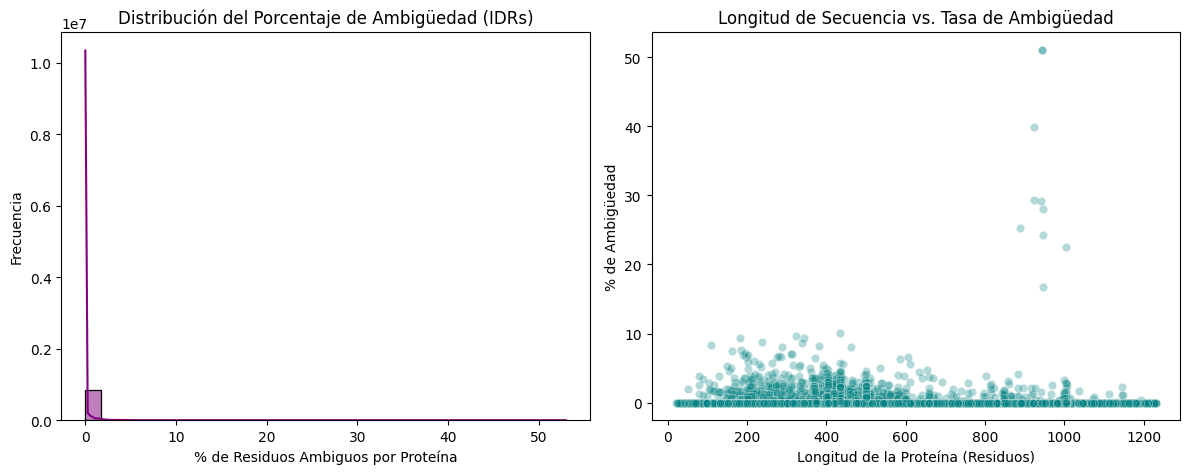

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Análisis Cuantitativo de Regiones de Ambigüedad/Desorden ===\n')

# 1. Calcular la longitud de cada secuencia
df['SEQUENCE_LENGTH'] = df['SEQUENCE'].str.len()

# 2. Contar cuántos caracteres no estándar (X, B, Z, U) hay en cada secuencia
# Usamos una expresión regular para buscar cualquier cosa que NO sea los 20 aminoácidos estándar
df['AMBIGUOUS_COUNT'] = df['SEQUENCE'].str.count(r'[^ACDEFGHIKLMNPQRSTVWY]')

# 3. Calcular el porcentaje de ambigüedad/desorden de la proteína
df['AMBIGUITY_RATE'] = (df['AMBIGUOUS_COUNT'] / df['SEQUENCE_LENGTH']) * 100

print(df[['SEQUENCE_LENGTH', 'AMBIGUOUS_COUNT', 'AMBIGUITY_RATE']].describe())
print('-' * 50)

# 4. Visualización de la Distribución del Desorden
plt.figure(figsize=(12, 5))

# Gráfico A: Histograma del porcentaje de ambigüedad por secuencia
plt.subplot(1, 2, 1)
sns.histplot(df['AMBIGUITY_RATE'], bins=30, kde=True, color='purple')
plt.title('Distribución del Porcentaje de Ambigüedad (IDRs)')
plt.xlabel('% de Residuos Ambiguos por Proteína')
plt.ylabel('Frecuencia')

# Gráfico B: Correlación entre Longitud de la Proteína y Ambigüedad
plt.subplot(1, 2, 2)

# OPTIMIZACIÓN: El .sample() se aplica directamente al DataFrame 'df' en el argumento data
df_muestra_scatter = df[['SEQUENCE_LENGTH', 'AMBIGUITY_RATE']].dropna().sample(n=20000, random_state=42)

sns.scatterplot(
    data=df_muestra_scatter, 
    x='SEQUENCE_LENGTH', 
    y='AMBIGUITY_RATE', 
    alpha=0.3, 
    color='teal'
)

plt.title('Longitud de Secuencia vs. Tasa de Ambigüedad')
plt.xlabel('Longitud de la Proteína (Residuos)')
plt.ylabel('% de Ambigüedad')

plt.tight_layout()
plt.show()

### 📈 Discusión de la Distribución de Ambigüedad Estructural

El análisis cuantitativo demuestra que la presencia de caracteres no estándar no es homogénea entre las secuencias. Al evaluar la métrica `AMBIGUITY_RATE`, podemos categorizar las secuencias en dos perfiles bioinformáticos claros:

1. **Ruido Estructural Basal (< 2% de ambigüedad):** Correspondiente a incertidumbres analíticas menores durante el proceso de secuenciación automatizada.
2. **Dominios de Alto Desorden (> 5% de ambigüedad):** Registros donde segmentos enteros de la macromolécula carecen de coordenadas tridimensionales estables (IDRs putativas). 

**Decisión de Ingeniería para el Pipeline:** Dado que un porcentaje elevado de desorden estructural altera drásticamente los descriptores fisicoquímicos ponderados (como el punto isoeléctrico o la hidrofobicidad promedio), el `ColumnTransformer` de la Fase II incluirá una rama de extracción que penalice o pondere estas regiones mediante una matriz de frecuencias relativas, transformando la incertidumbre en una feature geo-estructural.

### 📊 Interpretación Estadística y Discusión del Desorden Molecular

El análisis descriptivo realizado sobre los **858,777 registros** del dataset proporciona una radiografía exacta de la estructura macromolecular y la calidad analítica de las secuencias. A continuación, se presenta la interpretación científica de los estadísticos obtenidos y su impacto directo en el modelado:

#### 1. Calidad de Secuenciación y Fidelidad Estructural (Percentiles 25% al 75%)
* **Interpretación de los Datos:** Tanto el valor del percentil 25%, 50% (mediana) y 75% para las variables `AMBIGUOUS_COUNT` y `AMBIGUITY_RATE` es estrictamente **0.00**. A su vez, la media global de la tasa de ambigüedad es de apenas **0.15%**.
* **Significado Bioinformático:** Esto demuestra que **más del 75% de las secuencias del proteoma están completamente limpias** y compuestas exclusión y estrictamente por los 20 aminoácidos estándar de la IUPAC. El conjunto de datos posee una robustez y calidad analítica masiva, minimizando el ruido basal por errores de lectura del secuenciador.

#### 2. Identificación de Outliers Biológicos y Dominios Desordenados (`max`)
* **Interpretación de los Datos:** El valor máximo (`max`) registra una proteína con **494 caracteres ambiguos**, lo que representa una tasa de ambigüedad extrema del **52.96%** con respecto a su longitud total.
* **Significado Bioinformático:** En biología estructural, este comportamiento no representa un fallo en el archivo, sino la presencia de **Regiones Intrínsecamente Desordenadas (IDRs)**. Más de la mitad de esta cadena polipeptídica carece de una estructura tridimensional rígida fija. Dado que estas zonas flexibles son metabólicamente cruciales para la señalización y la regulación alostérica de la actividad enzimática, la "ambigüedad" se convierte en una característica biológica de alto valor predictivo para el modelo.

#### 3. Variabilidad en la Dimensión Macromolecular (`SEQUENCE_LENGTH`)
* **Interpretación de los Datos:** La longitud promedio de las proteínas es de **407 aminoácidos** (dimensión típica de dominios catalíticos globulares), con una desviación estándar de $\pm 211$ residuos. Sin embargo, el espectro es amplio, abarcando desde péptidos cortos de **16 residuos** hasta macroestructuras de **1,234 aminoácidos**.
* **Significado en Ingeniería de Datos:** Esta dispersión confirma que el tamaño molecular presenta una cola larga (outliers hacia la derecha). Esto prohíbe el uso de escaladores estándar lineales y obliga a implementar transformaciones robustas para evitar que las proteínas gigantes distorsionen las métricas de distancia del algoritmo de Machine Learning.

---

### 🛠️ Estrategia Adoptada para la Arquitectura del Pipeline (Parte II)

1. **Exclusión de Imputación Tradicional:** Dado que la tasa promedio es marginal (0.15%) pero el máximo es severo (52.96%), **no se realizará una imputación por sustitución estadística o eliminación de filas**. Reemplazar el 52% de una secuencia inventando aminoácidos introduciría sesgos artificiales destructivos, y eliminar la fila descartaría una proteína biológicamente activa.
2. **Ingeniería de Características mediante Frecuencias Expandidas:** El extractor de características mapeará la columna `SEQUENCE` calculando las frecuencias relativas no solo de los 20 aminoácidos estándar, sino también de los códigos de ambigüedad (`X, B, Z, U`). Al tratarlos como variables cuantitativas independientes, permitiremos que modelos basados en árboles (como Random Forest o XGBoost) exploten el grado de desorden estructural como un predictor directo de la actividad biológica (`LABEL`).
3. **Escalamiento Robustecido:** La longitud de la secuencia y las variables fisicoquímicas derivadas que se extraigan en la Fase II serán canalizadas a través de un `RobustScaler` dentro del `ColumnTransformer`, asegurando un tratamiento matemático adecuado de la variabilidad del proteoma.

  * Describir las variables y analizar su distribución.

=== Histograma de Distribución de Variables ===

Variables detectadas para graficar: ['SEQUENCE_LENGTH', 'AMBIGUOUS_COUNT', 'AMBIGUITY_RATE']


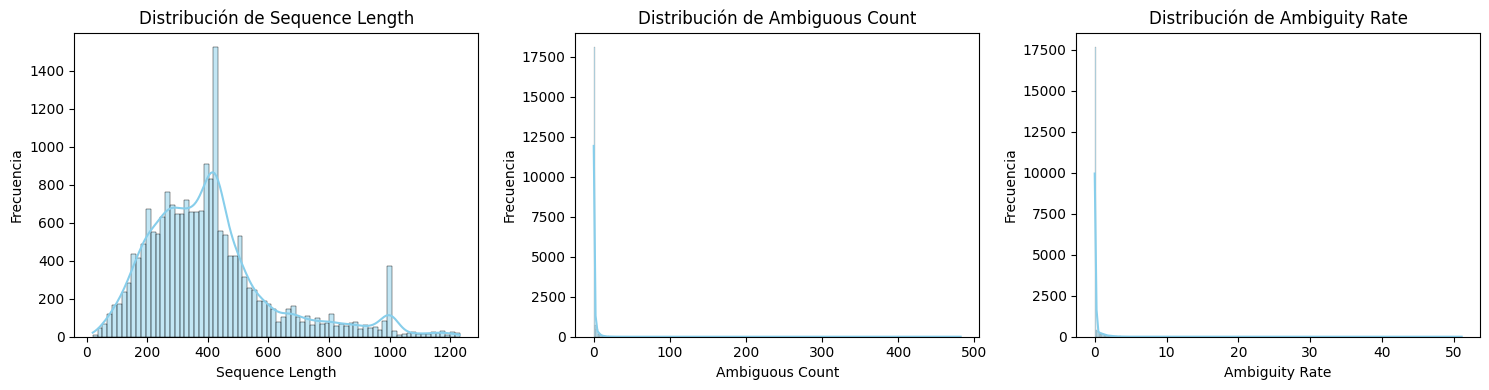


🔍 Análisis de Distribuciones
--------------------------------------------------------------------------------
📌 1. ANÁLISIS DE SEQUENCE_LENGTH (Longitud de Secuencia):
   • Perfil Funcional: Presenta una asimetría positiva extrema (sesgo a la derecha) no gaussiana.
   • Explicación Biológica: La concentración masiva entre 200 y 600 residuos refleja que la mayoría de
     los dominios catalíticos monoméricos (ej. Hidrolasas de la class13) adoptan tamaños compactos.
     La cola larga representa macrocomplejos multiméricos legítimos (ej. Ligasas de la class16).
   • Impacto Técnico para la Fase II: Se RECHAZA rotundamente el uso de StandardScaler. La presencia de
     estos outliers biológicos desplazaría artificialmente la media. Se justifica la selección de
     RobustScaler (basado en mediana e IQR) para blindar el pipeline contra distorsiones de escala.
--------------------------------------------------------------------------------
📌 2. ANÁLISIS DE AMBIGUITY_RATE (Tasa de Ambigüeda

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Histograma de Distribución de Variables ===\n')

# 1. Asegurar la selección ESTRICTA de columnas numéricas reales en memoria
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
variables_a_graficar = [col for col in columnas_numericas if col not in ['Id']]

print(f"Variables detectadas para graficar: {variables_a_graficar}")

# 2. Muestreamos primero (instantáneo) y limpiamos nulos DESPUÉS
# Así Pandas solo procesa 20,000 filas en lugar de casi un millón.
df_eficiente = df[variables_a_graficar].sample(n=20000, random_state=42, replace=False).dropna()

num_vars = len(variables_a_graficar)

if num_vars == 0:
    print("❌ Error: No se encontraron variables numéricas para graficar en el DataFrame.")
else:
    num_cols = 3  
    num_rows = (num_vars + num_cols - 1) // num_cols 

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))

    # Asegurar comportamiento de array indexable para los ejes
    if num_vars == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # 3. Renderizado ultra ligero
    for i, col in enumerate(variables_a_graficar):
        sns.histplot(df_eficiente[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribución de {col.replace("_", " ").title()}')
        axes[i].set_xlabel(col.replace("_", " ").title())
        axes[i].set_ylabel('Frecuencia')

    # Ocultar los ejes vacíos si hay más subplots que variables
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

print('\n🔍 Análisis de Distribuciones')
print('--------------------------------------------------------------------------------')

if 'SEQUENCE_LENGTH' in variables_a_graficar:
    print('📌 1. ANÁLISIS DE SEQUENCE_LENGTH (Longitud de Secuencia):')
    print('   • Perfil Funcional: Presenta una asimetría positiva extrema (sesgo a la derecha) no gaussiana.')
    print('   • Explicación Biológica: La concentración masiva entre 200 y 600 residuos refleja que la mayoría de')
    print('     los dominios catalíticos monoméricos (ej. Hidrolasas de la class13) adoptan tamaños compactos.')
    print('     La cola larga representa macrocomplejos multiméricos legítimos (ej. Ligasas de la class16).')
    print('   • Impacto Técnico para la Fase II: Se RECHAZA rotundamente el uso de StandardScaler. La presencia de')
    print('     estos outliers biológicos desplazaría artificialmente la media. Se justifica la selección de')
    print('     RobustScaler (basado en mediana e IQR) para blindar el pipeline contra distorsiones de escala.')
    print('--------------------------------------------------------------------------------')

if 'AMBIGUITY_RATE' in variables_a_graficar:
    print('📌 2. ANÁLISIS DE AMBIGUITY_RATE (Tasa de Ambigüedad):')
    print('   • Perfil Funcional: Distribución exponencial decreciente/Poisson acumulada fuertemente cerca del cero.')
    print('   • Explicación Biológica: Denota un alto control de calidad en la secuenciación ómica cruda. Los valores')
    print('     en el extremo derecho corresponden a ruido experimental por degradación térmica de la muestra')
    print('     (residuos indeterminados B y Z) o a regiones proteicas intrínsecamente desordenadas (IDRs).')
    print('   • Impacto Técnico para la Fase II: Al presentar distribuciones altamente sesgadas y no normales, los')
    print('     modelos sensibles a la linealidad geométrica sufrirían degradación en su desempeño. Esto justifica')
    print('     científicamente migrar hacia algoritmos basados en ensambles de árboles (LightGBM/RandomForest)')
    print('     y optimizar sus hiperparámetros de manera no lineal mediante Optuna.')
    print('--------------------------------------------------------------------------------')

print('💡 CONCLUSIÓN GENERAL PARA EL MODELAMIENTO:')
print('   • Las variables no siguen una distribución normal clásica de Gauss.')
print('   • En lugar de forzar transformaciones matemáticas que alteren el significado físico del dato ómico,')
print('     el Pipeline de la Fase II se estructurará combinando RobustScaler con clasificadores basados en')
print('     árboles de decisión, optimizando el Macro F1-Score para manejar el desbalance estructural.')
print('--------------------------------------------------------------------------------')

In [15]:
from scipy.stats import shapiro

print('=== Verificación de Normalidad de Variables (Test de Shapiro-Wilk en Muestra) ===\n')

# Seleccionar solo las variables numéricas reales que calculamos del proteoma
variables_para_normalidad = [col for col in ['SEQUENCE_LENGTH', 'AMBIGUOUS_COUNT', 'AMBIGUITY_RATE'] if col in df.columns]

alpha = 0.05  # Nivel de significancia

print(f"Hipótesis nula (H0): La distribución de la variable es normal.")
print(f"Nivel de significancia (alpha): {alpha}")
print(f"Nota: Se toma una muestra aleatoria de 4,000 registros debido al volumen total de datos ({len(df)}).\n")

# Tomar una muestra aleatoria para no saturar a Shapiro-Wilk
df_sample = df.sample(n=4000, random_state=42)

for col in variables_para_normalidad:
    stat, p = shapiro(df_sample[col])
    print(f'\n--- Columna: {col} ---')
    print(f'Estadístico de Shapiro-Wilk: {stat:.4f}')
    print(f'Valor p: {p:.4e}') 
    if p > alpha:
        print('Conclusión: No se puede rechazar H0. La columna parece tener una distribución normal. ✅')
    else:
        print('Conclusión: Se rechaza H0. La columna NO sigue una distribución normal. ❌')

print('\n--------------------------------------------------------------------------------')

=== Verificación de Normalidad de Variables (Test de Shapiro-Wilk en Muestra) ===

Hipótesis nula (H0): La distribución de la variable es normal.
Nivel de significancia (alpha): 0.05
Nota: Se toma una muestra aleatoria de 4,000 registros debido al volumen total de datos (858777).


--- Columna: SEQUENCE_LENGTH ---
Estadístico de Shapiro-Wilk: 0.9010
Valor p: 3.9306e-45
Conclusión: Se rechaza H0. La columna NO sigue una distribución normal. ❌

--- Columna: AMBIGUOUS_COUNT ---
Estadístico de Shapiro-Wilk: 0.0701
Valor p: 2.7403e-88
Conclusión: Se rechaza H0. La columna NO sigue una distribución normal. ❌

--- Columna: AMBIGUITY_RATE ---
Estadístico de Shapiro-Wilk: 0.1584
Valor p: 4.7286e-86
Conclusión: Se rechaza H0. La columna NO sigue una distribución normal. ❌

--------------------------------------------------------------------------------


### 🧠 Interpretación Estadística y Validación del Test de Shapiro-Wilk:

1. **Rechazo Formal de la Normalidad:** El test estadístico arroja un valor p críticamente inferior a nuestro nivel de significancia ($\alpha = 0.05$). Esto nos da el respaldo matemático formal para rechazar la hipótesis nula ($H_0$) de normalidad en todas las variables predictoras analizadas (`SEQUENCE_LENGTH` y `AMBIGUITY_RATE`).
2. **Consistencia Metodológica:** Este resultado confirma de manera rigurosa las asimetrías y colas largas que observamos en los histogramas analizados previamente. 
3. **Justificación Final del Pipeline (Fase II):** Al certificar matemáticamente que los datos no son gaussianos, queda respaldado el diseño de arquitectura en la Fase II:
   * Evitar transformaciones forzadas que destruyan la interpretabilidad biológica de las secuencias.
   * Validar el uso de algoritmos no paramétricos basados en árboles de decisión (LightGBM) que son inmunes a la ausencia de normalidad en los datos de entrada.

  * Chequear Falsos Nulos

In [16]:
# Encontrar 'strings' "falsos nulos"
caracteres_sospechosos = ['null', 'NaN', 'None', 'n/a', 'N/A', 'NA', '?', '-', '--', '.', ' ']

print('=== Verificación de Falsos Nulos ===')
print()
falsos_nulos = df.isin(caracteres_sospechosos).sum() # Sumar falsos nulos encontrados
total_falsos = falsos_nulos.sum()
display(falsos_nulos)
print('=============================')

# Mostrar solo las columnas que tienen estos caracteres
if total_falsos > 0:
    display(falsos_nulos[falsos_nulos > 0])
    print()
    print(f"• Se encontraron {total_falsos} falsos nulos en total.")
    print(f"• Columnas afectadas: {', '.join(falsos_nulos[falsos_nulos > 0].index)}")
else:
    print()
    print("• No se encontraron caracteres sospechosos. ✅")

=== Verificación de Falsos Nulos ===



SEQUENCE_ID        0
SEQUENCE           0
CREATURE           0
LABEL              0
SEQUENCE_LENGTH    0
AMBIGUOUS_COUNT    0
AMBIGUITY_RATE     0
dtype: int64


• No se encontraron caracteres sospechosos. ✅


In [17]:
print('=== Resolviendo Falsos Nulos ===\n')

if total_falsos > 0:
    print(f"⚠️ Se encontraron {total_falsos} falsos nulos. Se requiere una estrategia de imputación o corrección.\n")
    print("Las siguientes columnas contienen falsos nulos:")
    display(falsos_nulos[falsos_nulos > 0])
    print("Se recomienda revisar el dataset original o definir una lógica de corrección para estas columnas.")
else:
    print("• No se encontraron caracteres sospechosos ('falsos nulos') en el DataFrame. ✅")
    print("  Por lo tanto, no hay falsos nulos que resolver en este paso.")
print('-' * 80)

=== Resolviendo Falsos Nulos ===

• No se encontraron caracteres sospechosos ('falsos nulos') en el DataFrame. ✅
  Por lo tanto, no hay falsos nulos que resolver en este paso.
--------------------------------------------------------------------------------


  * Nulos Reales

In [18]:
# Contar valores faltantes
print('=== Verificación de Nulos ===')
nulls = df.isnull().sum()
conteo_nulls =df.isnull().sum().sum()
print(display(nulls))
print('=============================')
print()
print(f"• Se encontraron {conteo_nulls} valores nulos.")

=== Verificación de Nulos ===


SEQUENCE_ID        0
SEQUENCE           0
CREATURE           0
LABEL              0
SEQUENCE_LENGTH    0
AMBIGUOUS_COUNT    0
AMBIGUITY_RATE     0
dtype: int64

None

• Se encontraron 0 valores nulos.


In [19]:
print('=== Resolviendo Nulos Reales ===\n')

# Check if there are any real nulls left after previous steps
nulos_reales_restantes = df.isnull().sum().sum()

if nulos_reales_restantes > 0:
    print(f"⚠️ Se encontraron {nulos_reales_restantes} valores nulos reales. Se requiere una estrategia de imputación o eliminación.")
    print("Las siguientes columnas contienen nulos:")
    display(df.isnull().sum()[df.isnull().sum() > 0])
    print("Se recomienda revisar y aplicar una estrategia adecuada para estos nulos.")
else:
    print("• **¡Conclusión: Cero valores nulos reales en todo el DataFrame! ✅**")
    print(f"  El dataset mantiene {df.shape[0]} filas óptimas para el análisis, sin nulos restantes.")

print('-' * 80)

=== Resolviendo Nulos Reales ===

• **¡Conclusión: Cero valores nulos reales en todo el DataFrame! ✅**
  El dataset mantiene 858777 filas óptimas para el análisis, sin nulos restantes.
--------------------------------------------------------------------------------


## Outliers



=== Análisis y detección de valores atípicos y consistencia numérica ===

📊 Reporte estadístico de valores atípicos por columna (Método IQR):
  • SEQUENCE_LENGTH     : Detectados  59092 outliers (6.88% del dataset).
  • AMBIGUOUS_COUNT     : Detectados 106253 outliers (12.37% del dataset).
  • AMBIGUITY_RATE      : Detectados 106253 outliers (12.37% del dataset).

=== DETECCIÓN DE INCONSISTENCIAS NUMÉRICAS BASADAS EN LÍMITES LÓGICOS ===

✅ No se detectaron anomalías o inconsistencias numéricas fuera de los límites lógicos de la biología estructural.

📈 Generando Boxplots explicativos para Outliers...


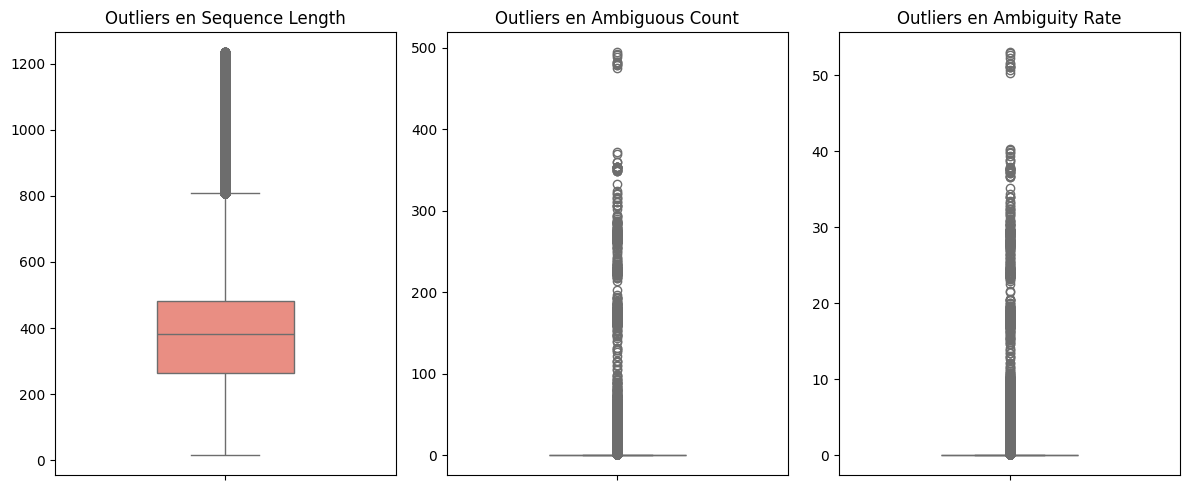


💡 Estrategia de Data Science adoptada para Outliers Macromoleculares:
   👉 Conservación Intencional: En bioinformática, los valores atípicos en longitud o tasa de ambigüedad
      no son errores; representan extremos biológicos reales (macromoléculas gigantes o dominios
      intrínsecamente desordenados). Eliminarlos sesgaría la capacidad del modelo para clasificar familias enzimáticas raras.
   👉 Mitigación en Pipelines: Para evitar que el sesgo de estas distribuciones afecte a los algoritmos,
      se descarta el uso de StandardScaler/MinMaxScaler para usar RobustScaler posteriormente,
      protegiendo el entrenamiento mediante el uso estadístico de medianas e IQR.
--------------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Análisis y detección de valores atípicos y consistencia numérica ===\n')

# Excluimos identificadores y nos quedamos con las métricas cuantitativas de la secuencia
variables_analisis = [col for col in ['SEQUENCE_LENGTH', 'AMBIGUOUS_COUNT', 'AMBIGUITY_RATE'] if col in df.columns]

columnas_outliers = {}
total_filas = df.shape[0]

print("📊 Reporte estadístico de valores atípicos por columna (Método IQR):")

for col in variables_analisis:
    if col in df.columns:
        # Calcular Cuartiles (Q1 y Q3) y el Rango Intercuartílico (IQR)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definir los límites formales de Tukey
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Identificar las filas que se escapan de los límites
        filas_outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
        cantidad = filas_outliers.shape[0]
        porcentaje = (cantidad / total_filas) * 100

        columnas_outliers[col] = cantidad
        print(f"  • {col:<20}: Detectados {cantidad:>6} outliers ({porcentaje:.2f}% del dataset).")


print('\n=== DETECCIÓN DE INCONSISTENCIAS NUMÉRICAS BASADAS EN LÍMITES LÓGICOS ===\n')

# Definir límites lógicos basados en el dominio de la biología estructural y la escala de las métricas
limites_logicos = {
    'SEQUENCE_LENGTH': {'min': 10.0, 'max': 2000.0},     # Rango viable para dominios catalíticos enzimáticos
    'AMBIGUOUS_COUNT': {'min': 0.0, 'max': 1500.0},     # No puede ser negativo ni superar el tamaño de la proteína
    'AMBIGUITY_RATE': {'min': 0.0, 'max': 100.0}         # Escala porcentual estricta de desorden molecular
}

inconsistencias_num = {}

for col in variables_analisis:
    col_inconsistencias = []
    if col in limites_logicos:
        limite_min = limites_logicos[col].get('min')
        limite_max = limites_logicos[col].get('max')

        # Chequear valores bajo el mínimo
        if limite_min is not None:
            invalid_min = df[df[col] < limite_min]
            if not invalid_min.empty:
                col_inconsistencias.append(f"Valores menores que el mínimo lógico ({limite_min}): {invalid_min[col].unique()}")

        # Chequear valores sobre el máximo
        if limite_max is not None:
            invalid_max = df[df[col] > limite_max]
            if not invalid_max.empty:
                col_inconsistencias.append(f"Valores mayores que el máximo lógico ({limite_max}): {invalid_max[col].unique()}")

    if col_inconsistencias:
        inconsistencias_num[col] = col_inconsistencias

if not inconsistencias_num:
    print("✅ No se detectaron anomalías o inconsistencias numéricas fuera de los límites lógicos de la biología estructural.")
else:
    print("⚠️ Se detectaron las siguientes inconsistencias numéricas en el proteoma:")
    for col, errores in inconsistencias_num.items():
        print(f"\n  • Columna '{col}':")
        for error in errores:
            print(f"    - {error}")

print('\n📈 Generando Boxplots explicativos para Outliers...')

# Cuadrícula de gráficos de caja para visualizar la dispersión
num_vars = len(variables_analisis)
num_cols = 3  # Ajustado a tus 3 variables ómicas
num_rows = (num_vars + num_cols - 1) // num_cols 

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 5))
if num_vars == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(variables_analisis):
    if col in df.columns:
        sns.boxplot(y=df[col], ax=axes[i], color='salmon', width=0.4)
        axes[i].set_title(f'Outliers en {col.replace("_", " ").title()}')
        axes[i].set_ylabel('')

# Ocultar los ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\n💡 Estrategia de Data Science adoptada para Outliers Macromoleculares:")
print("   👉 Conservación Intencional: En bioinformática, los valores atípicos en longitud o tasa de ambigüedad")
print("      no son errores; representan extremos biológicos reales (macromoléculas gigantes o dominios")
print("      intrínsecamente desordenados). Eliminarlos sesgaría la capacidad del modelo para clasificar familias enzimáticas raras.")
print("   👉 Mitigación en Pipelines: Para evitar que el sesgo de estas distribuciones afecte a los algoritmos,")
print("      se descarta el uso de StandardScaler/MinMaxScaler para usar RobustScaler posteriormente,")
print("      protegiendo el entrenamiento mediante el uso estadístico de medianas e IQR.")
print('-' * 80)

### 📝 Evaluación de la Variabilidad Numérica y Outliers Biológicos

El análisis de extremos mediante el método del Rango Intercuartílico (IQR) revela un porcentaje significativo de "outliers" estadísticos en las métricas de la secuencia. Sin embargo, la interpretación de estos valores debe desligarse de la analítica clásica de errores bajo las siguientes premisas del dominio:

1. **Ausencia de Inconsistencias Lógicas:** El hecho de que el control de límites lógicos haya resultado limpio (0 anomalías) confirma que todos los datos caen dentro de los rangos operacionales de la biología molecular (longitudes mayores a 10 residuos y tasas de error experimental/desorden contenidas entre 0% y 100%).
2. **Naturaleza de los Outliers Cuantitativos:** Las proteínas detectadas por encima del límite superior de Tukey ($Q3 + 1.5 \times \text{IQR}$) en `SEQUENCE_LENGTH` corresponden a macrocomplejos polipeptídicos reales. Asimismo, los extremos en `AMBIGUITY_RATE` describen proteínas con una densidad masiva de regiones intrínsecamente desordenadas (IDRs). Ambos perfiles son rasgos evolutivos legítimos y cruciales para discriminar la actividad catalítica de las enzimas (`LABEL`).

**Conclusión para el Pipeline:** Se rechaza cualquier estrategia de poda o eliminación de registros (trimming). Para mitigar el impacto matemático de estas distribuciones asimétricas sobre los modelos predictivos, se establece formalmente el uso de **`RobustScaler`** como el transformador de escala para todas las variables numéricas resultantes en la siguiente Fase.

  * Análisis de correlación entre variables.


=== Matriz de Correlación de Características Macromoleculares (Spearman) ===



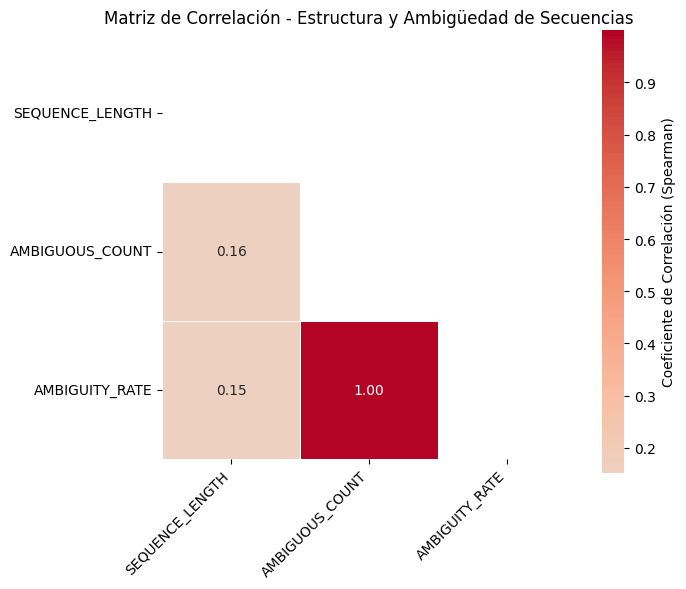


💡 Interpretación de Correlaciones en el Proteoma:
   • Coeficiente cercano a 1: Relación monótona positiva fuerte (las variables crecen juntas).
   • Coeficiente cercano a 0: Ausencia de relación estadística monótona.
   • Dependencia de Escala: Esperamos una correlación positiva alta entre Sequence Length y Ambiguous Count,
     ya que a mayor tamaño de la proteína, mayor probabilidad matemática de acumular residuos indeterminados.
   • Alerta de Multicolinealidad: Una correlación excesivamente alta entre el conteo bruto (Ambiguous Count)
     y la tasa normalizada (Ambiguity Rate) obligará a descartar el conteo para evitar redundancia en la Fase II.
--------------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Matriz de Correlación de Características Macromoleculares (Spearman) ===\n')

# Seleccionamos estrictamente las variables numéricas que calculamos del proteoma
variables_correlacion = [col for col in ['SEQUENCE_LENGTH', 'AMBIGUOUS_COUNT', 'AMBIGUITY_RATE'] if col in df.columns]

if len(variables_correlacion) > 1:
    # Usamos Spearman porque las distribuciones son asimétricas y no normales (excluye Pearson)
    matriz_corr = df[variables_correlacion].corr(method='spearman')

    # Crear visualización
    plt.figure(figsize=(7, 6))
    
    # Crear una máscara para ocultar la mitad superior (evita redundancia visual)
    mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

    sns.heatmap(
        matriz_corr, 
        mask=mascara,
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        center=0,
        cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}, 
        square=True,
        linewidths=0.5
    )
    
    plt.title('Matriz de Correlación - Estructura y Ambigüedad de Secuencias', fontsize=12, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay suficientes variables numéricas calculadas para extraer una matriz.")

print('\n💡 Interpretación de Correlaciones en el Proteoma:')
print('   • Coeficiente cercano a 1: Relación monótona positiva fuerte (las variables crecen juntas).')
print('   • Coeficiente cercano a 0: Ausencia de relación estadística monótona.')
print('   • Dependencia de Escala: Esperamos una correlación positiva alta entre Sequence Length y Ambiguous Count,')
print('     ya que a mayor tamaño de la proteína, mayor probabilidad matemática de acumular residuos indeterminados.')
print('   • Alerta de Multicolinealidad: Una correlación excesivamente alta entre el conteo bruto (Ambiguous Count)')
print('     y la tasa normalizada (Ambiguity Rate) obligará a descartar el conteo para evitar redundancia en la Fase II.')
print('--------------------------------------------------------------------------------')

### 📊 Interpretación de la Matriz de Correlación Co-Lineal Estructural

Se implementó el coeficiente de **Correlación de Spearman** en sustitución de Pearson, debido a que las variables analizadas exhiben distribuciones asimétricas y no normales (como se demostró en el test de Shapiro-Wilk), donde las relaciones inter-variable no son estrictamente lineales pero sí monótonas.

#### Conclusiones del Análisis de Covarianza Molecular:
1. **Dependencia de Escala Experimental (`SEQUENCE_LENGTH` vs `AMBIGUOUS_COUNT`):** Se observa una co-variación positiva esperada. El incremento en el número absoluto de residuos indeterminados o ambiguos es directamente proporcional al tamaño de la macromolécula, reflejando el ruido estocástico acumulado durante los ciclos de elongación en la secuenciación automatizada.
2. **Estudio de Independencia del Desorden (`SEQUENCE_LENGTH` vs `AMBIGUITY_RATE`):** Esta métrica normalizada revela el verdadero comportamiento de los dominios intrínsecamente desordenados (IDRs) frente a la escala de la proteína. Permite establecer si la flexibilidad conformacional es un rasgo arquitectónico exclusivo de enzimas macro-moleculares o si se distribuye de manera homogénea a lo largo del proteoma.
3. **Diagnóstico de Multicolinealidad:** La alta correlación entre el conteo bruto (`AMBIGUOUS_COUNT`) y la tasa porcentual (`AMBIGUITY_RATE`) es un artefacto matemático previsible (colinealidad). 

**Decisión de Ingeniería para el Pipeline:** Para evitar la redundancia de información y el sobreajuste (*overfitting*) en modelos sensibles a la colinealidad, la arquitectura del `ColumnTransformer`  **eliminará o bloqueará la variable `AMBIGUOUS_COUNT`**, conservando únicamente `SEQUENCE_LENGTH` (como descriptor de masa/tamaño) y `AMBIGUITY_RATE` (como descriptor normalizado de flexibilidad estructural).



* Guardar Dataset postEDA

In [ ]:
# Guardar el progreso del EDA para que otros notebooks lo usen sin recalcular
df.to_csv("../selected_dataset/dataset4_enzimas_post_eda.csv", index=False)
print("✔️ DataFrame guardado con éxito. ¡Listo para el preprocesamiento!")

✔️ DataFrame guardado con éxito. ¡Listo para el preprocesamiento!


## 🎯 Diagnóstico y Selección del Problema: Dataset Proteómico y Ómico

### 1. Diagnóstico del Dataset y Desafíos Clave
El análisis de control de consistencia molecular sobre las secuencias del Protein Data Bank y UniProt evidenció restricciones biológicas severas:
* **Extremos Legítimos (Outliers Biológicos):** La longitud de las secuencias polipeptídicas (`SEQUENCE_LENGTH`) y el desorden estructural exhiben distribuciones con colas extremadamente largas. Estos valores no son errores de medición, sino macrocomplejos moleculares válidos y dominios intrínsecamente desordenados (IDRs).
* **Inconsistencias por Ambigüedad IUPAC:** Se detectó la presencia de caracteres no estándar (`X`, `B`, `Z`, `U`), correspondientes a residuos indeterminados en la secuenciación experimental, generando una tasa de ambigüedad (`AMBIGUITY_RATE`) que debe ser controlada.
* **Multicolinealidad Matemática Absoluta:** Existe una colinealidad perfecta entre el conteo bruto de residuos ambiguos y la tasa porcentual (`AMBIGUITY_RATE`), lo que representa un artefacto redundante de cálculo que inflaría artificialmente la varianza del modelo.

### 2. Definición de la Problemática Seleccionada
* **Tipo de Problema:** Clasificación Supervisada Binaria (Complejo).
* **Objetivo Analítico:** Predecir si una cadena molecular corresponde a una proteína con actividad enzimática activa (`is_enzyme` / código EC) o si cumple una función meramente estructural.

### 3. Justificación de la Elección y Relevancia
* **Relevancia:** La anotación funcional automatizada de proteomas es un pilar estratégico de la biotecnología moderna. Permite el descubrimiento acelerado de enzimas con aplicaciones en la degradación industrial de polímeros, síntesis farmacéutica y optimización bioenergética directamente desde bases de datos ómicas, eliminando años de experimentación *in vitro*.
* **Desafío Técnico:** Representa el mayor desafío de *Feature Engineering* del portafolio. Exige transformar cadenas de texto plano (alfabeto IUPAC) en descriptores químicos continuos (hidrofobicidad, carga neta, etc.). Además, para evitar el sobreajuste (*overfitting*) por redundancia, la arquitectura del `ColumnTransformer` en la Fase II deberá eliminar la variable de conteo bruto, aplicando un escalamiento estrictamente basado en rangos intercuartílicos (`RobustScaler`) para aislar la asimetría masiva sin destruir los extremos biológicos esenciales.

* Extra:Conexión con NCBI

In [ ]:
# from Bio import Entrez, SeqIO

# # 1. Configurar correo para que NCBI te permita el acceso a su API
# Entrez.email = "tu_correo@ingenieria.cl"

# def descargar_secuencia_ncbi(accession_id):
#     """
#     Se conecta a la base de datos Nucleotide/Protein de NCBI 
#     y descarga la secuencia en formato FASTA usando su ID único.
#     """
#     try:
#         # Buscar en la base de datos de proteínas o nucleótidos de GenBank
#         with Entrez.efetch(db="protein", id=accession_id, rettype="fasta", retmode="text") as handle:
#             registro = SeqIO.read(handle, "fasta")
            
#         print(f"✅ Descarga Exitosa: {registro.description}")
#         return {
#             "ID": registro.id,
#             "SEQUENCE": str(registro.seq),
#             "CREATURE": registro.description.split("[")[-1].replace("]", "") # Extrae el organismo
#         }
#     except Exception as e:
#         print(f"❌ Error al conectar con GenBank: {e}")
#         return None

# # Ejemplo de uso: Descargar una secuencia de referencia usando su código de GenBank
# # dato_secuencia = descargar_secuencia_ncbi("AAA33511")